In [1]:
src_path = "/Users/deepakdhull/data/recsys/ml-25m"
! ls "/Users/deepakdhull/data/recsys/ml-25m/"

README.txt        genome-tags.csv   movies.csv        tags.csv
genome-scores.csv links.csv         ratings.csv


In [2]:
import re
import gc
import pyspark
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql import types as T
from pyspark.sql import Window
import numpy as np
import matplotlib.pyplot as plt
# Create Spark session
spark = SparkSession.builder \
    .appName("ALS_DATA_PREP") \
    .config("spark.executor.memory", "4g") \
    .config("spark.driver.memory", "4g") \
    .config("spark.executor.memoryOverhead", "512") \
    .config("spark.driver.memoryOverhead", "512") \
    .getOrCreate()

24/10/20 14:42:13 WARN Utils: Your hostname, Deepaks-MacBook-Pro.local resolves to a loopback address: 127.0.0.1; using 192.168.1.44 instead (on interface en0)
24/10/20 14:42:13 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
24/10/20 14:42:13 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


In [3]:
rating_df = spark.read.csv(f'{src_path}/ratings.csv', header=True, inferSchema=True)
movie_df = spark.read.csv(f"{src_path}/movies.csv", header=True, inferSchema=True)
tag_df = spark.read.csv(f"{src_path}/tags.csv", header=True, inferSchema=True)

In [4]:
rating_df.show(2), movie_df.show(2), tag_df.show(2)

+------+-------+------+----------+
|userId|movieId|rating| timestamp|
+------+-------+------+----------+
|     1|    296|   5.0|1147880044|
|     1|    306|   3.5|1147868817|
+------+-------+------+----------+
only showing top 2 rows

+-------+----------------+--------------------+
|movieId|           title|              genres|
+-------+----------------+--------------------+
|      1|Toy Story (1995)|Adventure|Animati...|
|      2|  Jumanji (1995)|Adventure|Childre...|
+-------+----------------+--------------------+
only showing top 2 rows

+------+-------+-------+----------+
|userId|movieId|    tag| timestamp|
+------+-------+-------+----------+
|     3|    260|classic|1439472355|
|     3|    260| sci-fi|1439472256|
+------+-------+-------+----------+
only showing top 2 rows



(None, None, None)

In [5]:
rating_df.count(), tag_df.count(), movie_df.count()

(25000095, 1093360, 62423)

In [11]:
# rating_df = rating_df.orderBy(F.col('timestamp'))

In [6]:
print("Number of Users:", rating_df.select(F.col("userId")).distinct().count())
print("Number of Movies:", rating_df.select(F.col("movieId")).distinct().count())

Number of Users: 162541


Number of Movies: 59047


#### Sample User Events

In [30]:
userId = 4
sample_user_rating_events_df = rating_df.filter(F.col('userId') == userId)
sample_user_tag_events_df = tag_df.filter(F.col('userId') == userId)

In [37]:
sample_user_rating_events_df = sample_user_rating_events_df.withColumn('event', F.lit('rate'))
sample_user_tag_events_df = sample_user_tag_events_df.withColumn('event', F.lit('tag'))

In [41]:
sample_user_rating_events_df = sample_user_rating_events_df.drop('rating')
sample_user_tag_events_df = sample_user_tag_events_df.drop('tag')

In [43]:
event_df = sample_user_rating_events_df.unionByName(sample_user_tag_events_df, allowMissingColumns=True)

In [44]:
event_df.count()

255

In [45]:
event_df = event_df.orderBy('timestamp')

In [47]:
df = event_df.toPandas()

In [52]:
df['binary'] = (df['event'] == 'tag').astype('int')

<Axes: >

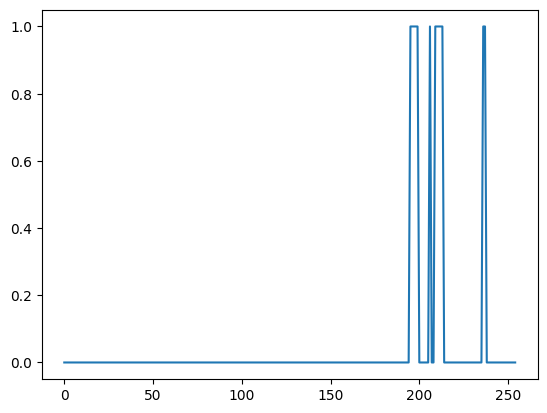

In [56]:
df['binary'].plot()

### Drive Features

In [5]:
# merge events from tag and rating
rating_df = rating_df.withColumn('event', F.lit('rate'))
tag_df = tag_df.withColumn('event', F.lit('tag'))

rating_df.show(2), tag_df.show(2)

+------+-------+------+----------+-----+
|userId|movieId|rating| timestamp|event|
+------+-------+------+----------+-----+
|     1|    296|   5.0|1147880044| rate|
|     1|    306|   3.5|1147868817| rate|
+------+-------+------+----------+-----+
only showing top 2 rows

+------+-------+-------+----------+-----+
|userId|movieId|    tag| timestamp|event|
+------+-------+-------+----------+-----+
|     3|    260|classic|1439472355|  tag|
|     3|    260| sci-fi|1439472256|  tag|
+------+-------+-------+----------+-----+
only showing top 2 rows



(None, None)

In [6]:
# event_df = rating_df.unionByName(tag_df, allowMissingColumns=True)
event_df = rating_df
event_df.show(2)

+------+-------+------+----------+-----+
|userId|movieId|rating| timestamp|event|
+------+-------+------+----------+-----+
|     1|    296|   5.0|1147880044| rate|
|     1|    306|   3.5|1147868817| rate|
+------+-------+------+----------+-----+
only showing top 2 rows



In [7]:
rating_df.filter(F.isnan('rating')).count()

0

In [8]:
tag_df.filter(F.isnan('tag')).count()

0

#### History Feature

In [8]:
recent_k = 50

In [9]:
window_spec = Window.partitionBy("userId").orderBy("timestamp").rowsBetween(-recent_k, -1)

In [10]:
# event_df = event_df.withColumn(
#     "recent_k_all_events", 
#     F.collect_list('movieId').over(window_spec)
# )

event_df = event_df.withColumn(
    "recent_k_rate_event",
    F.collect_list(F.when(F.col("event") == "rate", F.col("movieId"))).over(window_spec)
)

# event_df = event_df.withColumn(
#     "recent_k_tag_event",
#     F.collect_list(F.when(F.col("event") == "tag", F.col("movieId"))).over(window_spec)
# )

event_df = event_df.withColumn(
    "recent_k_rate_value",
    F.collect_list(F.when(F.col("event") == "rate", F.col("rating"))).over(window_spec)
)

# event_df = event_df.withColumn(
#     "recent_k_tag_value",
#     F.collect_list(F.when(F.col("event") == "rate", F.col("tag"))).over(window_spec)
# )

In [11]:
event_df.show(2)

+------+-------+------+---------+-----+-------------------+-------------------+
|userId|movieId|rating|timestamp|event|recent_k_rate_event|recent_k_rate_value|
+------+-------+------+---------+-----+-------------------+-------------------+
|    28|    380|   4.0|951086053| rate|                 []|                 []|
|    28|   1573|   4.0|951086053| rate|              [380]|              [4.0]|
+------+-------+------+---------+-----+-------------------+-------------------+
only showing top 2 rows



#### Categorical Features

##### Movie Features

In [12]:
movie_df.select("title").show(10, truncate=False)

+----------------------------------+
|title                             |
+----------------------------------+
|Toy Story (1995)                  |
|Jumanji (1995)                    |
|Grumpier Old Men (1995)           |
|Waiting to Exhale (1995)          |
|Father of the Bride Part II (1995)|
|Heat (1995)                       |
|Sabrina (1995)                    |
|Tom and Huck (1995)               |
|Sudden Death (1995)               |
|GoldenEye (1995)                  |
+----------------------------------+
only showing top 10 rows



In [13]:
movie_df = movie_df.withColumn("year_movie_release", F.regexp_extract(F.col("title"), r"\((\d{4})\)", 1))
movie_df = movie_df.drop("year")
movie_df = movie_df.withColumn("title", F.regexp_replace(F.col("title"), r"\s*\(\d{4}\)", ""))

In [14]:
movie_df.show(2)

+-------+---------+--------------------+------------------+
|movieId|    title|              genres|year_movie_release|
+-------+---------+--------------------+------------------+
|      1|Toy Story|Adventure|Animati...|              1995|
|      2|  Jumanji|Adventure|Childre...|              1995|
+-------+---------+--------------------+------------------+
only showing top 2 rows



In [15]:
event_df = event_df.join(movie_df, on='movieId', how='inner')

In [16]:
event_df.show(2)

+-------+------+------+---------+-----+-------------------+-------------------+---------+--------------------+------------------+
|movieId|userId|rating|timestamp|event|recent_k_rate_event|recent_k_rate_value|    title|              genres|year_movie_release|
+-------+------+------+---------+-----+-------------------+-------------------+---------+--------------------+------------------+
|    380|    28|   4.0|951086053| rate|                 []|                 []|True Lies|Action|Adventure|...|              1994|
|   1573|    28|   4.0|951086053| rate|              [380]|              [4.0]| Face/Off|Action|Crime|Dram...|              1997|
+-------+------+------+---------+-----+-------------------+-------------------+---------+--------------------+------------------+
only showing top 2 rows



In [20]:
event_df.write.mode("overwrite").parquet(f"{src_path}/pq/")

### Feature Exploration and Drive New Features

#### Categorical Features
- userId
- movieId
- genres
- title
- tag
- event # drived either 'tag' or 'rate' 

#### Date Time Features
- timestamp

#### History Features
Need to create these features, k in recent_k need to pick
k would be hyperparameter for data creation, eg. k = 20
- **recent_k_all_events**
- **recent_k_rate_events** 
- **recent_k_tag_events** 